In [1]:
#@markdown # Read export from Nexis Uni

import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

tqdm.pandas()

try:
  from journalisticfeelings import export_preannotations, extract_articles_from_folder
except ImportError:
  !pip3 install -U 'git+ssh://git@git.lwp.rug.nl:/team-data-science/2021/journalistic-feelings/journalisticfeelings.git'
  from journalisticfeelings import export_preannotations, extract_articles_from_folder

path = '/slow-data/journalisticfeelings/' #@param {"type": "string"}
os.chdir(path)

docx_path = './data/nexis-uni-export/' #@param {"type": "string"}

export_filename = './data/nexis-uni-export.p3' #@param {"type": "string"}

section_groups_path = 'data/secties.xlsx' #@param {"type": "string"}

In [2]:
#@markdown # Read articles

if 'articles_' not in globals():
  articles_ = extract_articles_from_folder(docx_path, njobs=40)
articles = articles_.copy()

  0%|          | 0/928 [00:00<?, ?it/s]

In [3]:
#@markdown # Clean up date and newspaper metadata

#@markdown * Use date from the docx-file, if not available from the zip-filename given during the export.
#@markdown * Clean up several weird dates
#@markdown * Ensure consistent paper names: Algemeen Dagblad, de Volkskrant and NRC Handelsblad
articles = articles_.copy()

articles['paper'].replace({'AD/Algemeen Dagblad': 'Algemeen Dagblad'}, inplace=True)
papers = articles['zip'].str.split('-date-').str[0].str.replace('AD_', '')
articles['paper'].fillna(papers, inplace=True)
articles[articles['paper'] != papers]

# Working with two locales seemed impossible, hence this quick fix
replacements = {'maandag': 'monday',
 'dinsdag': 'tuesday',
 'woensdag': 'wednesday',
 'donderdag': 'thursday',
 'vrijdag': 'friday',
 'zaterdag': 'saturday',
 'zondag': 'sunday',
 'januari': 'january',
 'februari': 'february',
 'maart': 'march',
 'april': 'april',
 'mei': 'may',
 'juni': 'june',
 'juli': 'july',
 'augustus': 'august',
 'september': 'september',
 'oktober': 'october',
 'november': 'november',
 'december': 'december'}

dates = articles['date'].str.lower()
for a, b in replacements.items():
  dates = dates.str.replace(a, b)
dates = dates.replace('december 6, 2003 saturday sunday 6 en 7 december 2003', 'december 6, 2003')
dates = dates.replace("7 january 2013 monday thursday prijzen friday industrie thursday overname tuesday risico's", 'january 7, 2013')
dates = pd.to_datetime(articles['zip'].str.split('-date-').str[1].str.split('-page-').str[0])
articles['date'].fillna(dates, inplace=True)

articles['date'] = pd.to_datetime(dates).dt.date

assert articles['date'].isna().sum() == 0

section_groups = pd.read_excel(section_groups_path).set_index('sectie')['cluster'].to_dict()
sections = articles['Section'].str.split(';', expand=True)

pages = pd.Series(None, index=sections.index, dtype=str)
for c in sections.columns[::-1]:
  found = sections[c].str.strip().str.extract('^(?:Blz|Pg)\. ([A-Z]{0,3}\d+[A-Z]?(?:[-,] ?[A-Z]{0,3}\d+[A-Z]?)*)$')
  pages.fillna(found[0], inplace=True)
  sections.loc[~found[0].isna(), c] = np.nan

articles['section group'] = sections[0].apply(lambda x: section_groups.get(x, 'other')).fillna('unknown')
articles['page'] = pages.str.extract('^(\d+)')[0].apply(lambda x: 'unknown' if x!=x else (f'{int(x):02d}' if int(x) <= 40 else '>40'))

In [4]:
#@markdown # Remove opinion pieces

#@markdown articles in sections which title contains one of these are removed: 
#@markdown `opinie`, `debat`, `trefpunt`, `forum`, `service`, `u-pagina`, `u pagina`, `advertentie`

page_expression = re.compile(r'(?:; ?|^)(?:Pg\.|pg\.|pagina|Blz\.|blz\.) ((?:BRS|CS|BB|WA|V|B|N|Z|G|E|U|K|W|M|T|R|S|L|v|ECO|SPO|BIN|BUI|KUN|VP|AP|VAN|OPI)?)([\,\d]+)')
articles['Page Prefix'], articles['Page'] = articles['Section'].str.extract(page_expression, expand=True)
articles['Section'] = articles['Section'].str.replace(page_expression, '')

garbage_expression = re.compile(r'[\-\d\, ]+$')
sections = articles['Section'].str.replace(garbage_expression, '').str.lower()

blacklist = sections.value_counts()
blacklist = blacklist[(
  blacklist.index.str.contains('opinie') |
  blacklist.index.str.contains('debat') |
  blacklist.index.str.contains('trefpunt') |
  blacklist.index.str.contains('forum') |
  blacklist.index.str.contains('service') |
  blacklist.index.str.contains('u-pagina') |
  blacklist.index.str.contains('u pagina') |
  blacklist.index.str.contains('advertentie')
)].index

articles = articles[~sections.isin(blacklist)]



In [5]:
#@markdown #Export
articles.to_pickle(export_filename)

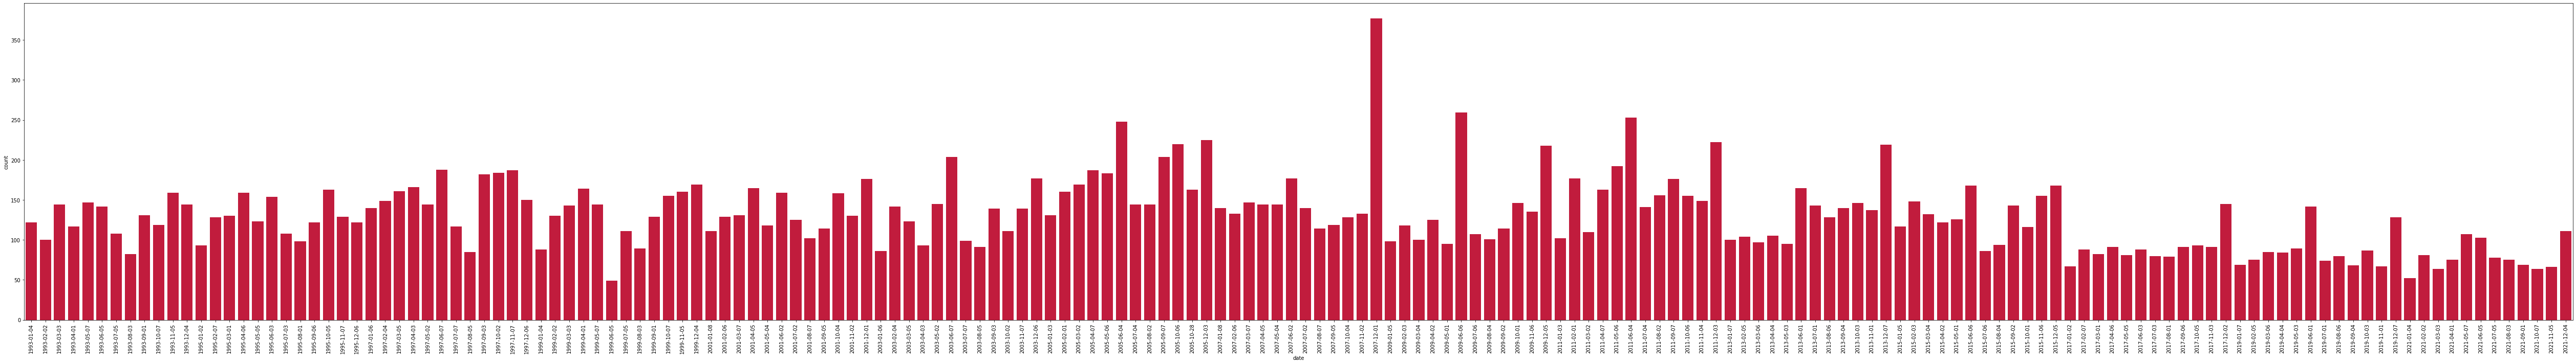

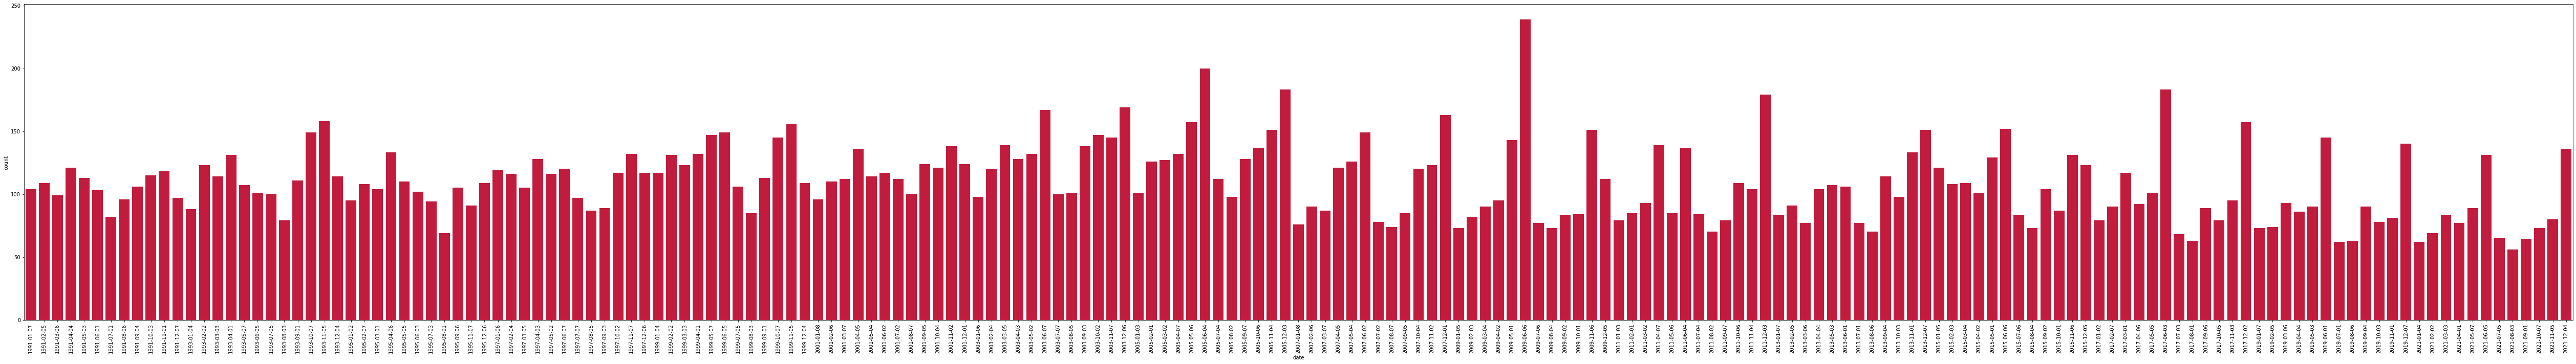

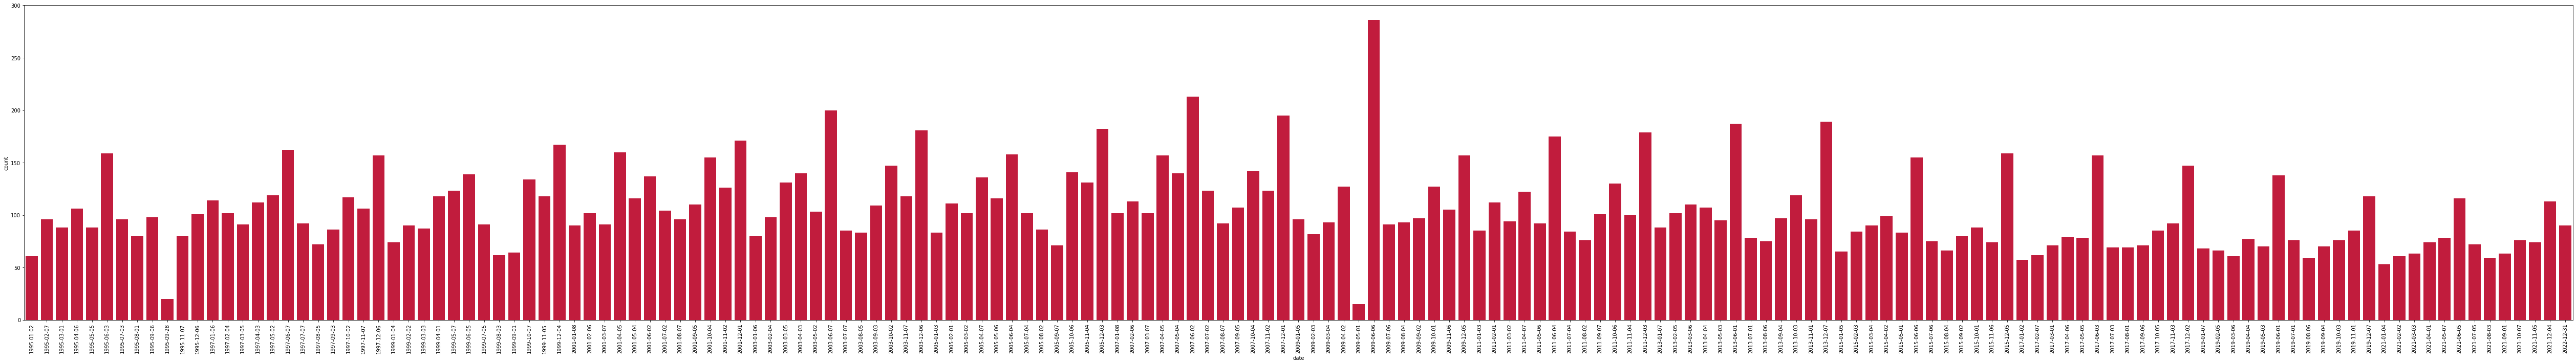

In [6]:
#@markdown # Article occurence per paper and date
import seaborn as sns

for paper, timeline in articles.groupby('paper'):
  timeline = timeline.groupby('date').apply(len).rename('count').reset_index()
  plt.figure(figsize=(70, 10))
  sns.barplot(data=timeline, x='date', y='count', color='#dc002d')
  timeline
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.savefig(f'results/dates-paper-{paper.replace("AD/", "")}.png')